# 1.4.4 Smoothing Images

## Kernel Convolution

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [23]:
l=1
kernel = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]],np.float32)

In [24]:
kernel

array([[ 0., -1.,  0.],
       [-1.,  4., -1.],
       [ 0., -1.,  0.]], dtype=float32)

In [25]:
img = np.random.randint(10, size=(12,12))
#img = np.ones((10,10),np.float32)

In [26]:
img

array([[0, 4, 6, 5, 0, 6, 1, 2, 4, 9, 1, 2],
       [6, 9, 4, 7, 1, 3, 8, 9, 5, 4, 8, 2],
       [8, 8, 5, 0, 8, 7, 9, 3, 9, 9, 9, 4],
       [7, 6, 7, 2, 6, 1, 6, 6, 7, 3, 5, 5],
       [8, 9, 6, 7, 1, 7, 1, 1, 4, 8, 8, 0],
       [7, 3, 9, 4, 7, 8, 6, 1, 5, 2, 5, 6],
       [9, 7, 5, 3, 1, 6, 0, 4, 5, 7, 0, 8],
       [5, 8, 2, 7, 7, 6, 6, 0, 8, 1, 2, 6],
       [1, 4, 3, 4, 8, 7, 2, 1, 0, 4, 3, 7],
       [5, 1, 6, 2, 9, 7, 9, 0, 9, 5, 4, 9],
       [8, 0, 0, 3, 3, 8, 3, 7, 5, 1, 7, 9],
       [5, 1, 7, 9, 0, 7, 0, 7, 6, 8, 2, 0]])

In [27]:
h,w=img.shape

In [28]:
print(h,w)

12 12


In [29]:
#[*range(-2,3)]

In [34]:
dst = np.zeros((h,w),np.int)

In [35]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i,j]=t        

In [36]:
img

array([[0, 4, 6, 5, 0, 6, 1, 2, 4, 9, 1, 2],
       [6, 9, 4, 7, 1, 3, 8, 9, 5, 4, 8, 2],
       [8, 8, 5, 0, 8, 7, 9, 3, 9, 9, 9, 4],
       [7, 6, 7, 2, 6, 1, 6, 6, 7, 3, 5, 5],
       [8, 9, 6, 7, 1, 7, 1, 1, 4, 8, 8, 0],
       [7, 3, 9, 4, 7, 8, 6, 1, 5, 2, 5, 6],
       [9, 7, 5, 3, 1, 6, 0, 4, 5, 7, 0, 8],
       [5, 8, 2, 7, 7, 6, 6, 0, 8, 1, 2, 6],
       [1, 4, 3, 4, 8, 7, 2, 1, 0, 4, 3, 7],
       [5, 1, 6, 2, 9, 7, 9, 0, 9, 5, 4, 9],
       [8, 0, 0, 3, 3, 8, 3, 7, 5, 1, 7, 9],
       [5, 1, 7, 9, 0, 7, 0, 7, 6, 8, 2, 0]])

In [37]:
dst

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,  14, -11,  18, -14, -10,  10,  18,  -6, -15,  16,   0],
       [  0,   4,   1, -22,  18,   7,  12, -21,  12,  11,  10,   0],
       [  0,  -7,   9, -12,  12, -22,   7,   7,   6, -17,  -5,   0],
       [  0,  13,  -8,  15, -23,  17, -16,  -8,  -5,  15,  14,   0],
       [  0, -20,  18, -10,  14,   6,  14, -12,   8, -17,   4,   0],
       [  0,   3,  -1,  -5, -19,   9, -22,  10,  -4,  20, -22,   0],
       [  0,  14, -15,  12,   6,  -2,  16, -19,  26, -17,  -2,   0],
       [  0,   3,  -4,  -4,   5,   5, -15,   2, -22,   7,  -5,   0],
       [  0, -11,  18, -14,  16,  -5,  24, -26,  26,   2,  -8,   0],
       [  0, -10, -16,  -2,  -8,  12, -12,  13,  -3, -21,  12,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]])

In [38]:
img = cv2.imread('lena.png', 0)

In [39]:
h,w=img.shape

In [40]:
dst = np.zeros((h-2*l,w-2*l),np.uint8)

In [41]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i-l,j-l]=t 

In [42]:
cv2.imshow('img',img)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

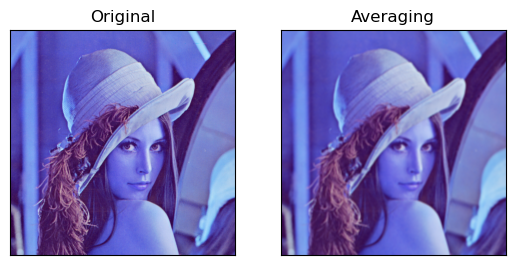

In [3]:
img = cv2.imread('Lenna.png')
kernel = np.ones((5,5),np.float32)/25
dst = cv2.filter2D(img,-1,kernel)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()

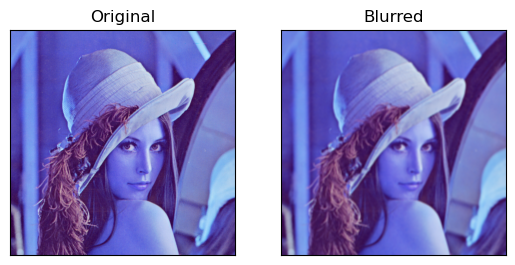

In [4]:
img = cv2.imread('Lenna.png')
blur = cv2.blur(img,(5,5))
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.show()

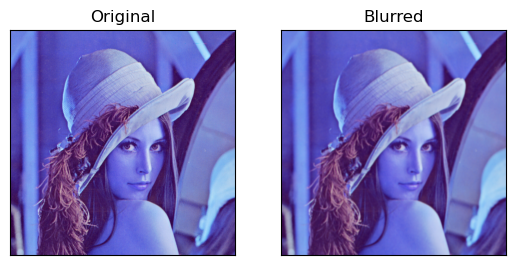

In [5]:
img = cv2.imread('Lenna.png')
blur = cv2.GaussianBlur(img,(5,5),0)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.show()

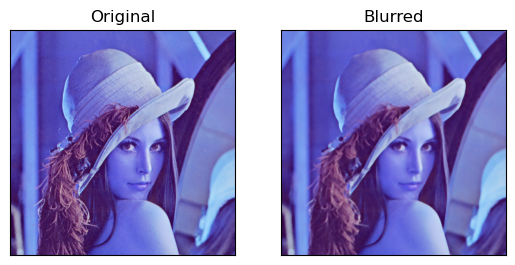

In [8]:
img = cv2.imread('Lenna.png')
median = cv2.medianBlur(img,5)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(median),plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.show()

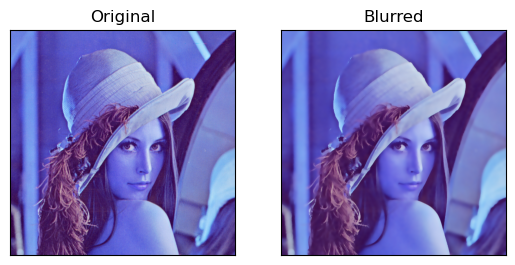

In [9]:
img = cv2.imread('Lenna.png')
blur = cv2.bilateralFilter(img,9,75,75)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.show()